# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from heart_failure.config.config import (
    RAW_DATA_DIR,
    INTERIM_DATA_DIR,
    AGE,
    SEX,
    RESTING_BP,
    CHOLESTEROL,
    FASTING_BS,
    HEART_DISEASE,
    OLDPEAK,
    ST_SLOPE,
    EXERCISE_ANGINA,
    MAX_HR,
    RESTING_ECG
)
from heart_failure.config.features import CONJ_RULES
from heart_failure.dataset import split_data
from heart_failure.plots import plot_cat_value_counts, plot_cat_target_distribution, plot_corr_matrix
from heart_failure.utils import target_pct_table_by_cat, cat_pct_distr_by_group

2026-06-18 12:08:08.705 | INFO     | heart_failure.config.config:<module>:11 - PROJ_ROOT path is: D:\heart_failure


In [2]:
df = pd.read_csv(RAW_DATA_DIR / "heart.csv")

## 1. Short information

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


The dataset contains a variety of features.

Categorical features include:
- Sex,
- ChestPainType,
- RestingECG,
- ExerciseAngina,
- FastingBS,
- ST_Slope.

Of these, the bicategorical features are:
- Sex,
- FastingBS,
- ExerciseAngina.

The remaining features, except Oldpeak (continuous), are discrete.

### 1.1 Null values

In [4]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Some features have not None, but the value 0, which theoretically shouldn't exist:

- RestingBP,
- Cholesterol

One more thing. The Cholesterol feature has a maximum value of 603. However, the internet says that such a value is theoretically possible.

In [3]:
obj_cols = df.select_dtypes(include=["object"]).columns
df[obj_cols] = df[obj_cols].astype("category")
df[FASTING_BS] = df[FASTING_BS].astype("category")

In [4]:
df[RESTING_BP] = df[RESTING_BP].replace(0, np.nan)
df[CHOLESTEROL] = df[CHOLESTEROL].replace(0, np.nan)

In [5]:
df.isna().sum().sort_values(ascending=False).head()

Cholesterol      172
RestingBP          1
Sex                0
Age                0
ChestPainType      0
dtype: int64

Given that the RestingBP feature only has one null value, this instance can be removed from the data.

For Cholesterol, the situation is slightly different. Nulls are present in more than 10 percent of the samples. Given the limited data, removing them is unlikely to be the best solution. Therefore, it's necessary to determine whether these missing values are related to other features and then decide what to do with them.

### 1.2 Duplicates

In [58]:
df.duplicated().sum()

np.int64(0)

There are no duplicates in the data.

## 2. Data distribution

### 2.1 Numeric features

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'RestingBP'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'MaxHR'}>],
       [<Axes: title={'center': 'Oldpeak'}>,
        <Axes: title={'center': 'HeartDisease'}>]], dtype=object)

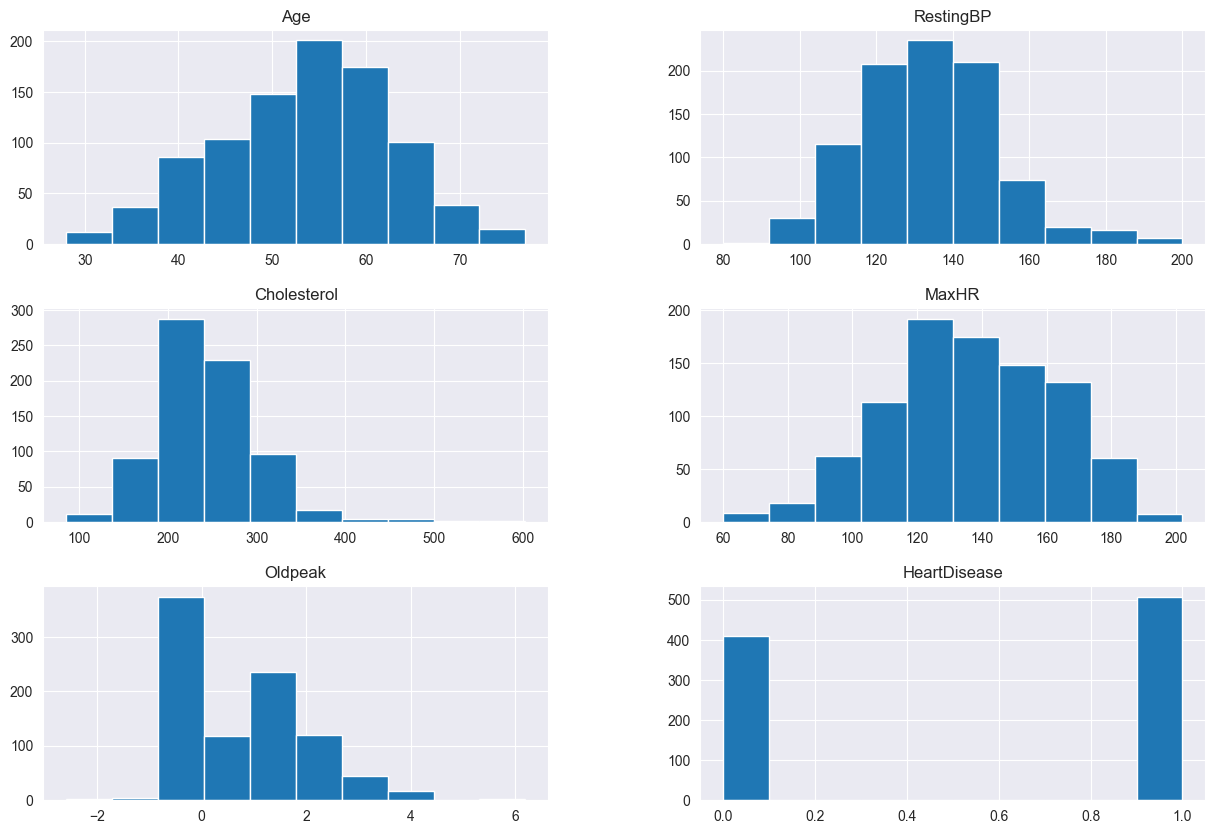

In [9]:
df.hist(figsize=(15, 10))

Some points that confused me:

- The Olpdeak feature has the most values in the range (-1; 0]. Are most of them zeros or other negative values? If it's zero, why zero? How does it differ from the other values?
- The Cholesterol feature, in addition to the extreme value of 600, also has very rare values in the range [400; 600]. Under what circumstances do these occur?

The classes are split almost equally.

### 2.2 Categorial features

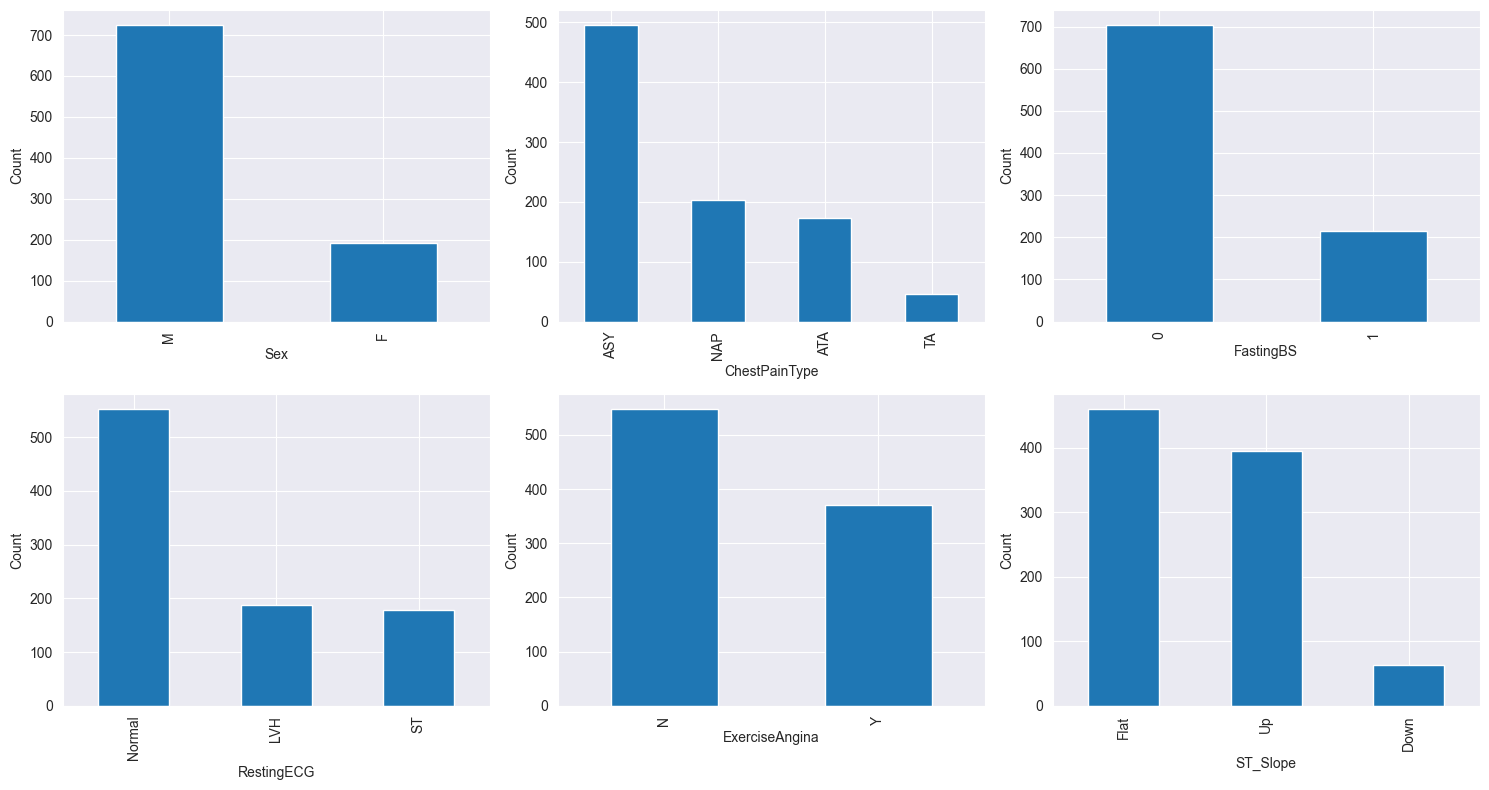

In [60]:
plot_cat_value_counts(df)

- The number of women in the data is significantly lower than that of men. Will there be enough representatives of both classes in the female population?
- Why are there relatively few cases of TA in ChestPainType and Down in ST_Slope? Judging by the internet description, these two types are strong indicators of heart disease. Will this be the case for me? Are there any other values associated with these rare cases?
- The FastingBS feature has significantly more 0s than 1s. Is the target for this feature proportionally divided?

Also, the normal range for indicators in men and women is usually different. Will the combination of features required to confirm the presence of Heart Disease differ in men and women?

I also need to determine how to implement feature encoding in the future.

### 2.3 Class distribution by features

Now I should only look at train data to avoid leakages.

In [6]:
df_train, df_val, df_test = split_data(df, stratify_func=lambda d: d[[SEX, HEART_DISEASE]])

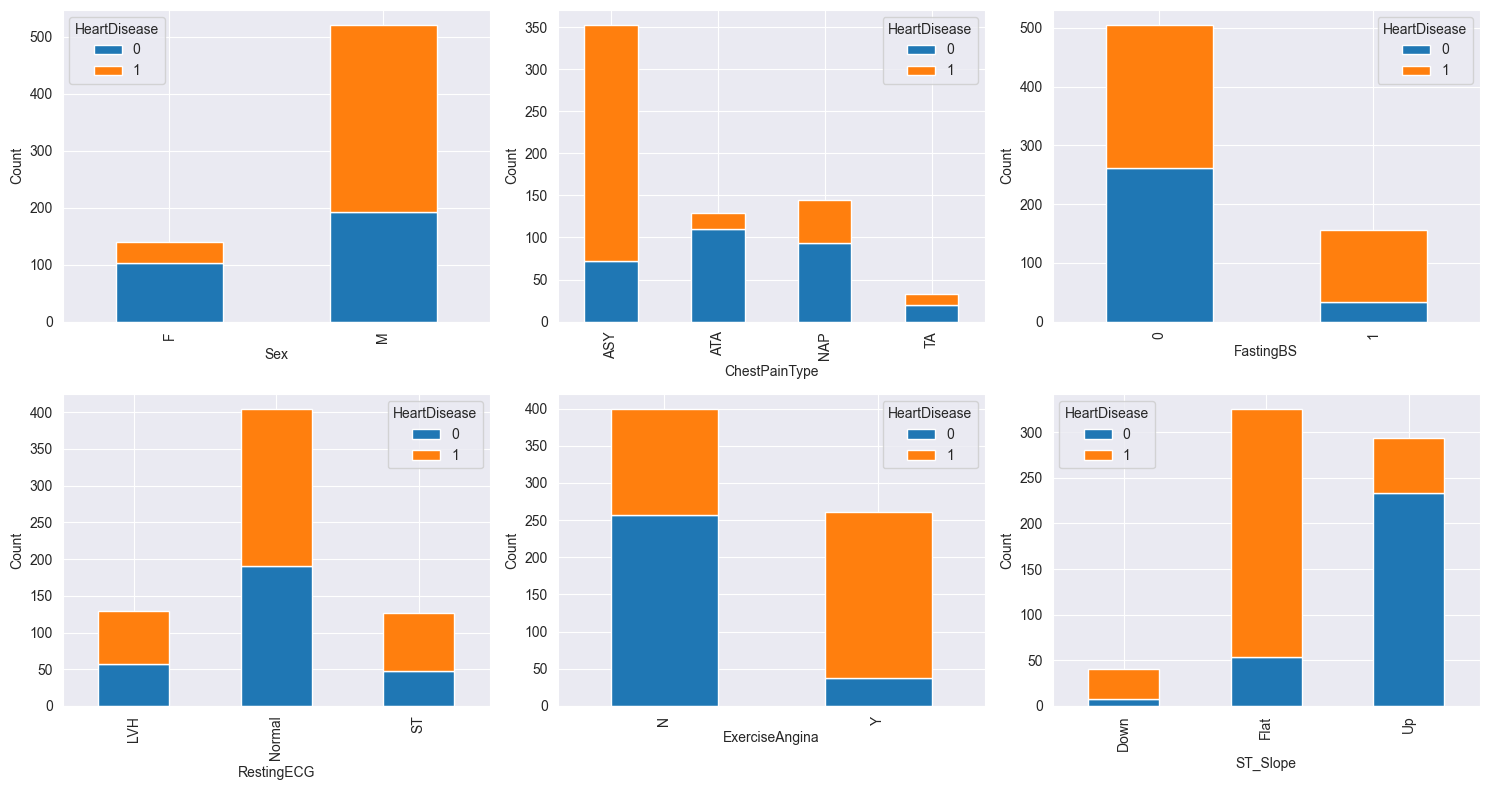

In [7]:
plot_cat_target_distribution(df_train, HEART_DISEASE)

The graphs show that certain values of some features are more or less likely to cause heart disease. For these features, the following should be examined. Does a low (high) percentage of illness mean that with this feature value, a person is less (more) likely to get disease (other features are both good and bad)? Or does a person with this feature value have good (bad) features on average, making the percentage of disease lower (higher)?

In [11]:
pct_df = target_pct_table_by_cat(df_train, HEART_DISEASE)
pct_df.loc[:, (pct_df <= 0.3).any(axis=0)]

variable     ChestPainType           ExerciseAngina FastingBS  ST_Slope  \
value                  ASY       ATA              Y         1      Down   
HeartDisease                                                              
0                 0.203966  0.852713       0.145594  0.219355  0.195122   
1                 0.796034  0.147287       0.854406  0.780645  0.804878   

variable                               Sex  
value             Flat        Up         F  
HeartDisease                                
0             0.166154  0.792517  0.741007  
1             0.833846  0.207483  0.258993

## 3. Correlation

In [12]:
corr_df = df_train.corr(numeric_only=True)
plot_corr_matrix(corr_df)

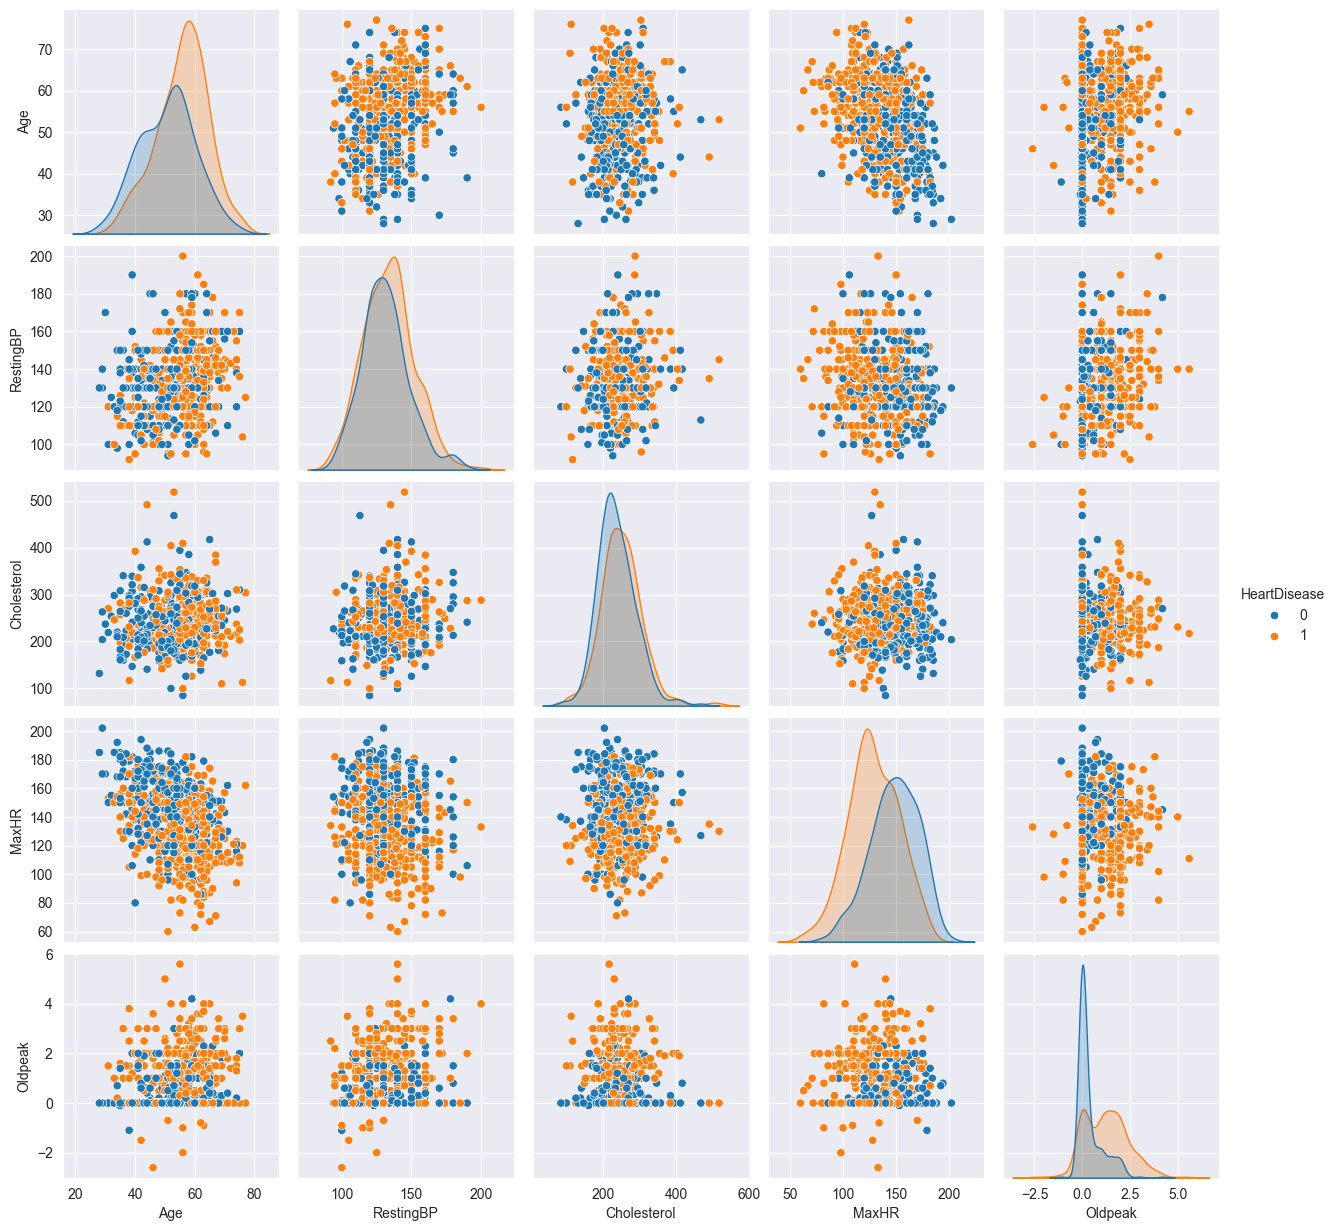

In [13]:
sns.pairplot(df_train, hue=HEART_DISEASE)
plt.show()

1. Oldpeak. Firstly, zeros, not just negative values, are indeed predominant here. Looking at the Oldpeak/Age graph, we can see that at Oldpeak=0 and Age<~60, almost no diseases are observed. For Oldpeak>0 values, the classes are mixed. This is also evident in the histogram by class: 0 appears much more frequently at target=0. Starting from a value of ~2.5, target=0 is almost never encountered.
2. MaxHR. In all graphs, higher values are more consistent with the absence of disease.
3. Cholesterol. There is no relationship with target. However, it is clear that even with large values of the feature (>400), there are cases where the disease is absent.
4. RestingBP. There is virtually no relationship with target.
5. Age. Higher age corresponds to a higher frequency of diseases.

## 4. Specific traits

### 4.1 Cholesterol

#### 4.1.1 Null values

In [14]:
null_mask = df_train[CHOLESTEROL].isna()
df_train.groupby(null_mask).describe()

Age                                                     \
             count       mean       std   min   25%   50%   75%   max   
Cholesterol                                                             
False        543.0  52.987109  9.438958  28.0  46.0  54.0  59.0  77.0   
True         117.0  56.264957  8.247668  34.0  52.0  57.0  62.0  74.0   

            RestingBP              ... Oldpeak      HeartDisease            \
                count        mean  ...     75%  max        count      mean   
Cholesterol                        ...                                       
False           543.0  133.189687  ...     1.5  5.6        543.0  0.482505   
True            116.0  129.637931  ...     1.5  3.7        117.0  0.880342   

                                                
                  std  min  25%  50%  75%  max  
Cholesterol                                     
False        0.500155  0.0  0.0  0.0  1.0  1.0  
True         0.325957  0.0  1.0  1.0  1.0  1.0  

[2 rows x 48 columns]

Key features of the group:
- The class ratio is 88:100, while in the rest of the data it's 48:100. This means this is a predominantly unhealthy group.
- All features previously noted as influencing the target have a distinctive median: Oldpeak is higher by 0.16, MaxHR is lower by 20, and Age is higher by 3.

In [15]:
cat_pct_distr_by_group(df_train, null_mask)

Sex           ChestPainType                                \
                    F         M           ASY       ATA       NAP        TA   
Cholesterol                                                                   
False        0.243094  0.756906      0.488029  0.226519  0.230203  0.055249   
True         0.059829  0.940171      0.752137  0.051282  0.170940  0.025641   

            FastingBS           RestingECG                    ExerciseAngina  \
                    0         1        LVH   Normal        ST              N   
Cholesterol                                                                    
False        0.828729  0.171271   0.224678  0.60221  0.173112       0.615101   
True         0.470085  0.529915   0.059829  0.65812  0.282051       0.555556   

                       ST_Slope                      
                    Y      Down      Flat        Up  
Cholesterol                                          
False        0.384899  0.051565  0.469613  0.478821  
True         0.444444  0.111111  0.598291  0.290598

The data is predominantly male. All features that correspond to a higher percentage of class 1 are also more common in this group.

I'm thinking of filling in the values as follows: divide the data into four groups by gender and age and fill in the median for each group.

In [ ]:
age_bins = pd.qcut(df[AGE], q=5)
df[CHOLESTEROL] = (
    df.groupby([SEX, age_bins])[CHOLESTEROL].transform(lambda s: s.fillna(s.median()))
)
df = df.dropna()
df.to_csv(INTERIM_DATA_DIR / "heart.csv", index=False)

In [17]:
df_train, df_val, df_test = split_data(df, stratify_func=lambda d: d[[SEX, HEART_DISEASE]])

#### 4.1.2 Huge rare values

In [18]:
huge_chol_mask = df_train[CHOLESTEROL] > df_train[CHOLESTEROL].quantile(0.977)
df_train.groupby(huge_chol_mask).describe()

Age                                                      \
             count       mean       std   min   25%   50%    75%   max   
Cholesterol                                                              
False        643.0  53.600311  9.251949  28.0  48.0  54.0  60.00  76.0   
True          16.0  53.500000  8.438009  40.0  47.0  54.0  57.25  67.0   

            RestingBP              ... Oldpeak      HeartDisease          \
                count        mean  ...     75%  max        count    mean   
Cholesterol                        ...                                     
False           643.0  132.727838  ...     1.5  5.6        643.0  0.5521   
True             16.0  143.437500  ...     1.9  2.0         16.0  0.5625   

                                                
                  std  min  25%  50%  75%  max  
Cholesterol                                     
False        0.497665  0.0  0.0  1.0  1.0  1.0  
True         0.512348  0.0  0.0  1.0  1.0  1.0  

[2 rows x 48 columns]

In [19]:
cat_pct_distr_by_group(df_train, huge_chol_mask)

Sex           ChestPainType                                \
                    F         M           ASY       ATA       NAP        TA   
Cholesterol                                                                   
False        0.206843  0.793157      0.522551  0.195956  0.228616  0.052877   
True         0.375000  0.625000      0.750000  0.125000  0.125000  0.000000   

            FastingBS           RestingECG                     ExerciseAngina  \
                    0         1        LVH    Normal        ST              N   
Cholesterol                                                                     
False        0.755832  0.244168   0.197512  0.603421  0.199067       0.598756   
True         0.812500  0.187500   0.250000  0.625000  0.125000       0.562500   

                       ST_Slope                      
                    Y      Down      Flat        Up  
Cholesterol                                          
False        0.401244  0.065319  0.502333  0.432348  
True         0.437500  0.000000  0.625000  0.375000

In [20]:
df_train[huge_chol_mask]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
613,58,M,ASY,140.0,385.0,1,LVH,135,N,0.3,Up,0
278,57,F,ASY,180.0,347.0,0,ST,126,Y,0.8,Flat,0
667,65,F,NAP,140.0,417.0,1,LVH,157,N,0.8,Up,0
872,55,M,ASY,132.0,353.0,0,Normal,132,Y,1.2,Flat,1
30,53,M,NAP,145.0,518.0,0,Normal,130,N,0.0,Flat,1
498,67,M,ASY,160.0,384.0,1,ST,130,Y,0.0,Flat,1
102,40,F,ASY,150.0,392.0,0,Normal,130,N,2.0,Flat,1
284,42,M,ASY,140.0,358.0,0,Normal,170,N,0.0,Up,0
256,55,F,ATA,130.0,394.0,0,LVH,150,N,0.0,Up,0
238,48,M,ASY,160.0,355.0,0,Normal,99,Y,2.0,Flat,1


The features across the groups are quite similar. However, the percentage of positive cases is slightly higher with higher cholesterol levels. In all cases where the disease is present, ST_Slope = Flat.

I want to check whether the percentage of cases increases with increasing cholesterol levels overall, and not just in this group?

#### 4.1.3 Increased cholesterol levels

In [21]:
df_train.groupby(pd.qcut(df_train[CHOLESTEROL], q=10), observed=False)[HEART_DISEASE].mean()

Cholesterol
(84.999, 186.0]    0.402985
(186.0, 209.0]     0.376812
(209.0, 222.0]     0.406250
(222.0, 230.0]     0.646154
(230.0, 234.0]     0.794118
(234.0, 244.5]     0.623188
(244.5, 263.0]     0.507692
(263.0, 277.0]     0.540984
(277.0, 305.0]     0.636364
(305.0, 518.0]     0.584615
Name: HeartDisease, dtype: float64

There is no strict monotonic relationship. At high rates (after a certain threshold), the disease incidence rate is, on average, higher than at low rates.

### 4.2 Oldpeak

In [22]:
zero_oldpeak_mask = df_train[OLDPEAK] == 0
df_train.groupby(zero_oldpeak_mask).describe()

Age                                                    RestingBP  \
         count       mean       std   min   25%   50%   75%   max     count   
Oldpeak                                                                       
False    389.0  55.997429  8.409769  31.0  51.0  57.0  62.0  76.0     389.0   
True     270.0  50.140741  9.269740  28.0  43.0  51.0  56.0  74.0     270.0   

                     ... Oldpeak      HeartDisease                           \
               mean  ...     75%  max        count      mean       std  min   
Oldpeak              ...                                                      
False    133.902314  ...     2.0  5.6        389.0  0.701799  0.458057  0.0   
True     131.670370  ...     0.0  0.0        270.0  0.337037  0.473575  0.0   

                             
         25%  50%  75%  max  
Oldpeak                      
False    0.0  1.0  1.0  1.0  
True     0.0  0.0  1.0  1.0  

[2 rows x 48 columns]

In [23]:
cat_pct_distr_by_group(df_train, zero_oldpeak_mask)

Sex           ChestPainType                                \
                F         M           ASY       ATA       NAP        TA   
Oldpeak                                                                   
False    0.167095  0.832905      0.642674  0.095116  0.200514  0.061697   
True     0.274074  0.725926      0.362963  0.337037  0.262963  0.037037   

        FastingBS           RestingECG                     ExerciseAngina  \
                0         1        LVH    Normal        ST              N   
Oldpeak                                                                     
False    0.714653  0.285347   0.228792  0.544987  0.226221       0.437018   
True     0.818519  0.181481   0.155556  0.688889  0.155556       0.829630   

                   ST_Slope                      
                Y      Down      Flat        Up  
Oldpeak                                          
False    0.562982  0.107969  0.650386  0.241645  
True     0.170370  0.000000  0.296296  0.703704

In [24]:
up_st_slope_mask = df_train[ST_SLOPE] == "Up"
df_train[up_st_slope_mask][OLDPEAK].describe()

count    284.000000
mean       0.299648
std        0.660041
min       -1.100000
25%        0.000000
50%        0.000000
75%        0.200000
max        4.000000
Name: Oldpeak, dtype: float64

As far as I understand, the value 0 most often occurs when ST_Slope=Up. And it's the norm. There's no strict correlation between Slope=Up and Oldpeak=0. But they occur together more often than with other values.

Will the disease rate be lower if we combine Up and 0?

In [25]:
mask = up_st_slope_mask & zero_oldpeak_mask
tmp = df_train.groupby(mask)[HEART_DISEASE].mean().rename("disease_pct").to_frame()
tmp["non_disease_pct"] = 1 - tmp["disease_pct"]
tmp.index.name = "mask"
tmp

,disease_pct,non_disease_pct
mask,,
False,0.737740,0.262260
True,0.094737,0.905263


This is the most accurate sign that the disease is not present. But we're still more interested in the circumstances under which the disease is most likely to be present.

### 4.3 Presence of heart disease

Let's look at the disease rate under different conditions. What will it be under different combinations of conditions? And what will be the disease rate for other cases not included in this mask?

In [31]:
conditions = {name: rule(df_train) for name, rule in CONJ_RULES.items()}
result = []

for names in combinations(conditions.keys(), 2):
    mask = np.logical_and.reduce([conditions[n] for n in names])

    result.append({
        "conditions": " & ".join(names),
        "count": mask.sum(),
        "disease_pct": df_train.loc[mask, HEART_DISEASE].mean(),
        "non_disease_pct": 1 - df_train.loc[mask, HEART_DISEASE].mean(),
        "unaccounted_diseases": (df_train.loc[~mask, HEART_DISEASE] == 1).sum(),
    })

result = pd.DataFrame(result)
count_mask = result["count"] >= 45
result[count_mask].sort_values(["disease_pct", "count"], ascending=False).head(10)

,conditions,count,disease_pct,non_disease_pct,unaccounted_diseases
43,FastingBS=1 & ST_Slope=Flat,98,0.959184,0.040816,270
36,ChestPain=ASY & FastingBS=1,101,0.950495,0.049505,268
5,Oldpeak>=2 & ExerciseAngina=Y,85,0.941176,0.058824,284
39,ExerciseAngina=Y & FastingBS=1,70,0.928571,0.071429,299
4,Oldpeak>=2 & ChestPain=ASY,91,0.923077,0.076923,280
8,Oldpeak>=2 & ST_Slope=Flat,88,0.920455,0.079545,283
35,ChestPain=ASY & ExerciseAngina=Y,211,0.914692,0.085308,171
38,ChestPain=ASY & ST_Slope=Flat,228,0.912281,0.087719,156
41,ExerciseAngina=Y & ST_Slope=Flat,200,0.905000,0.095000,183
20,MaxHR<=150 & ExerciseAngina=Y,238,0.894958,0.105042,151


ChestPain has the highest percentage of occurrences in pairs, but this doesn't mean they're all different pairs. All conditions can be present in the same cases. The remaining characteristics, except age, appear at roughly the same rate.

However, each pair individually doesn't cover the entire spectrum of diseases: outside the mask, ~50% belong to class 1.

For the baseline, we could experiment with combining conditions (taking OR of the best ones or adding combinations of three) to achieve a better result. For now, the point is that, based on individual criteria, we can say that a disease is very likely to appear here.

### 4.4 Gender differences

#### 4.4.1 Feature difference by disease

In [33]:
df_train.groupby([SEX, HEART_DISEASE], observed=False).describe()

Age                                                      \
                  count       mean       std   min    25%   50%   75%   max   
Sex HeartDisease                                                              
F   0             103.0  51.330097  9.343540  30.0  45.00  52.0  57.0  74.0   
    1              36.0  55.972222  8.395530  33.0  50.75  57.5  62.0  73.0   
M   0             192.0  50.593750  9.437120  28.0  43.00  52.0  57.0  75.0   
    1             328.0  55.807927  8.490487  31.0  51.00  57.0  62.0  76.0   

                 RestingBP              ...   MaxHR        Oldpeak            \
                     count        mean  ...     75%    max   count      mean   
Sex HeartDisease                        ...                                    
F   0                103.0  129.446602  ...  164.00  192.0   103.0  0.394175   
    1                 36.0  141.861111  ...  154.00  170.0    36.0  1.058333   
M   0                192.0  132.255208  ...  165.00  202.0   192.0  0.371354   
    1                328.0  133.554878  ...  143.25  195.0   328.0  1.285366   

                                                      
                       std  min  25%  50%   75%  max  
Sex HeartDisease                                      
F   0             0.606634  0.0  0.0  0.0  0.65  2.0  
    1             1.104892  0.0  0.0  1.0  1.50  4.0  
M   0             0.702920 -1.1  0.0  0.0  0.40  4.2  
    1             1.146661 -2.0  0.0  1.3  2.00  5.6  

[4 rows x 40 columns]

In [34]:
cat_pct_distr_by_group(df_train, [df_train[SEX], df_train[HEART_DISEASE]])

Sex      ChestPainType                                \
                    F    M           ASY       ATA       NAP        TA   
Sex HeartDisease                                                         
F   0             1.0  0.0      0.223301  0.398058  0.320388  0.058252   
    1             1.0  0.0      0.777778  0.055556  0.138889  0.027778   
M   0             0.0  1.0      0.255208  0.359375  0.312500  0.072917   
    1             0.0  1.0      0.756098  0.048780  0.155488  0.039634   

                 FastingBS           RestingECG                      \
                         0         1        LVH    Normal        ST   
Sex HeartDisease                                                      
F   0             0.912621  0.087379   0.223301  0.621359  0.155340   
    1             0.694444  0.305556   0.222222  0.666667  0.111111   
M   0             0.869792  0.130208   0.177083  0.661458  0.161458   
    1             0.649390  0.350610   0.201220  0.557927  0.240854   

                 ExerciseAngina            ST_Slope                      
                              N         Y      Down      Flat        Up  
Sex HeartDisease                                                         
F   0                  0.893204  0.106796  0.000000  0.252427  0.747573  
    1                  0.444444  0.555556  0.083333  0.805556  0.111111  
M   0                  0.859375  0.140625  0.041667  0.145833  0.812500  
    1                  0.368902  0.631098  0.094512  0.762195  0.143293

While the mean and median RestingBP levels in men do not differ when grouped by class, this is not the case for women. With disease, RestingBP is, on average, higher.

There is a difference between cholesterol levels by class in both men and women. However, in women, this difference is much greater. Since the average age is 50, women have higher levels on average than men. This explains the similarity in mean cholesterol levels for groups M_1 and F_0.

The mean MaxHR differs more significantly between M_0 and M_1 than between F_0 and F_1. However, the values for M_0 and F_0 are approximately the same.

RestingECG=ST is as common in women with disease as without it. However, there is a difference in men.

As a result, the combination of conditions for the disease likely differs between men and women.

- Does RestingBP have a greater impact on the risk of disease in women?
- Does Cholesterol have a greater impact on the risk of disease in women?
- Does a lower MaxHR affect the risk of disease in women?
- Does a lower RestingECG affect the risk of disease in women?

I'm also still interested why such a low percentage of women get disease.

#### 4.4.2 Age groups

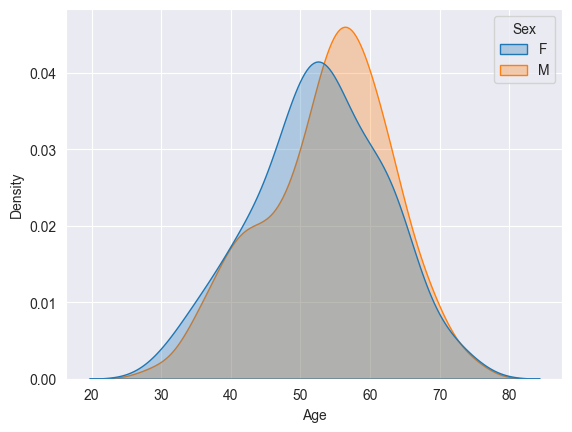

In [35]:
sns.kdeplot(df_train, x=AGE, hue=SEX, fill=True, common_norm=False, alpha=0.3)
plt.show()

The average age of women and men who are healthy is around 50. At this age, women experience menopause, after which cholesterol levels rise, increasing the risk of disease. Visually, women have more values before 50, while men have more values after 50. This may explain the difference in percentages.

#### 4.4.3 Influence of different features

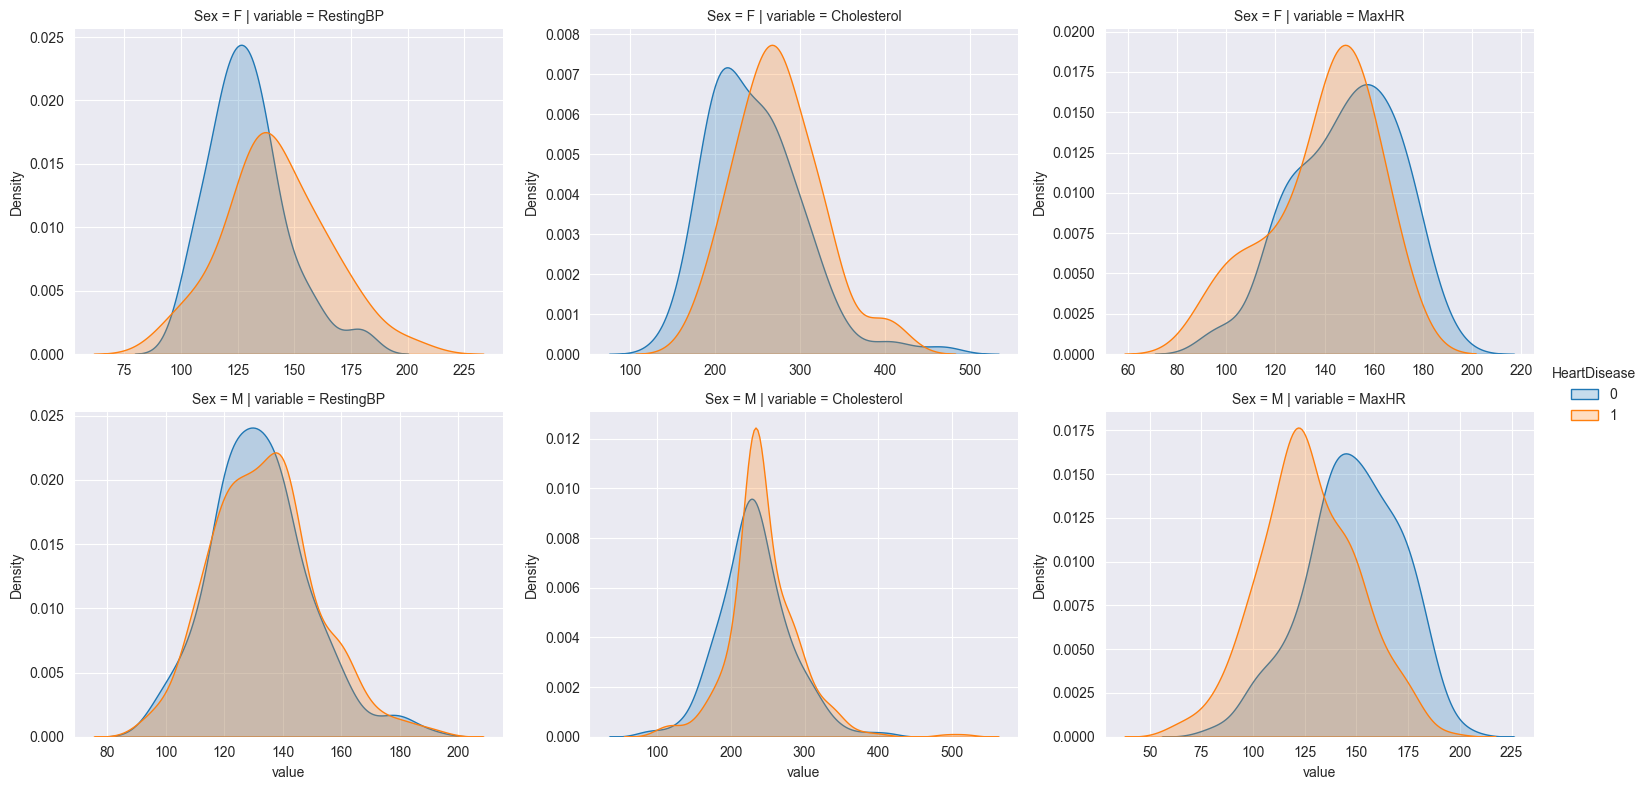

In [36]:
x_vars = [RESTING_BP, CHOLESTEROL, MAX_HR]
tmp = df_train.melt([SEX, HEART_DISEASE], x_vars)

g = sns.FacetGrid(
    tmp,
    row=SEX,
    col="variable",
    hue=HEART_DISEASE,
    sharex=False,
    sharey=False,
    height=4,
    aspect=1.3,
)

g.map(sns.kdeplot, "value", fill=True)
g.add_legend()
plt.show()

All cases are indeed different for men and women. RestingBP and Cholesterol are more important in women, while MaxHR is less important (but still has an impact).

### 4.5 RestingECG

Does the feature have any impact on the target? Perhaps different disease conditions are responsible for different values?

In [38]:
df_train.groupby([RESTING_ECG, HEART_DISEASE], observed=False).describe()

Age                                                \
                         count       mean        std   min   25%   50%   75%   
RestingECG HeartDisease                                                        
LVH        0              57.0  53.771930  10.184052  28.0  47.0  54.0  59.0   
           1              74.0  58.175676   7.247783  35.0  56.0  58.5  62.0   
Normal     0             191.0  50.005236   9.024235  29.0  43.0  51.0  56.0   
           1             207.0  53.874396   8.998580  31.0  48.0  54.0  61.0   
ST         0              47.0  50.744681   9.379599  30.0  45.0  53.0  56.5   
           1              83.0  58.590361   6.711905  40.0  55.0  58.0  63.0   

                              RestingBP              ...   MaxHR         \
                          max     count        mean  ...     75%    max   
RestingECG HeartDisease                              ...                  
LVH        0             74.0      57.0  130.964912  ...  169.00  202.0   
           1             76.0      74.0  138.243243  ...  149.25  195.0   
Normal     0             75.0     191.0  130.696335  ...  166.00  194.0   
           1             74.0     207.0  131.536232  ...  145.00  182.0   
ST         0             68.0      47.0  134.000000  ...  154.00  185.0   
           1             74.0      83.0  138.012048  ...  140.00  163.0   

                        Oldpeak                                             \
                          count      mean       std  min    25%  50%   75%   
RestingECG HeartDisease                                                      
LVH        0               57.0  0.571930  0.823051  0.0  0.000  0.2  0.80   
           1               74.0  1.437838  1.209064 -0.8  0.175  1.4  2.40   
Normal     0              191.0  0.319895  0.605868 -1.1  0.000  0.0  0.35   
           1              207.0  1.166184  1.107878 -2.0  0.000  1.1  2.00   
ST         0               47.0  0.387234  0.683220 -0.1  0.000  0.0  0.40   
           1               83.0  1.348193  1.158148 -1.0  0.500  1.4  2.00   

                              
                         max  
RestingECG HeartDisease       
LVH        0             4.2  
           1             4.0  
Normal     0             2.0  
           1             5.6  
ST         0             3.0  
           1             5.0  

[6 rows x 40 columns]

The risk of disease is higher for the ST value, and the risk is lowest for the Normal value. The average age for the Normal value is lower than for the others, and we remember that the risk of the disease increases with age.

Looking at the average MaxHR, the value for ST for both classes is, on average, lower than for LVH, even though the age groups are roughly the same. This means that a relatively low MaxHR value does not always indicate the presence of the disease.

### 4.6 Other features with low (high) percentage of disease

#### 4.6.1 FastingBS

In [40]:
df_train.groupby([FASTING_BS, HEART_DISEASE], observed=False).describe()

Age                                                 \
                        count       mean       std   min    25%   50%    75%   
FastingBS HeartDisease                                                         
0         0             261.0  50.168582  9.323787  28.0  43.00  51.0  56.00   
          1             238.0  54.920168  8.668164  31.0  50.00  56.0  61.00   
1         0              34.0  56.088235  8.338911  39.0  51.25  55.5  60.75   
          1             126.0  57.531746  7.833964  34.0  53.25  58.0  62.00   

                             RestingBP              ...   MaxHR         \
                         max     count        mean  ...     75%    max   
FastingBS HeartDisease                              ...                  
0         0             74.0     261.0  130.701149  ...  165.00  202.0   
          1             76.0     238.0  133.857143  ...  145.00  195.0   
1         0             75.0      34.0  135.676471  ...  161.75  194.0   
          1             74.0     126.0  135.357143  ...  145.00  176.0   

                       Oldpeak                                               \
                         count      mean       std  min    25%   50%    75%   
FastingBS HeartDisease                                                        
0         0              261.0  0.366667  0.667890 -1.1  0.000  0.00  0.500   
          1              238.0  1.394958  1.177091 -1.0  0.025  1.40  2.000   
1         0               34.0  0.476471  0.687578  0.0  0.000  0.05  0.950   
          1              126.0  1.013492  1.035324 -2.0  0.000  1.05  1.775   

                             
                        max  
FastingBS HeartDisease       
0         0             4.2  
          1             5.6  
1         0             2.3  
          1             4.0  

[4 rows x 40 columns]

In [41]:
cat_pct_distr_by_group(df_train, [df_train[FASTING_BS], df_train[HEART_DISEASE]])

Sex           ChestPainType                      \
                               F         M           ASY       ATA       NAP   
FastingBS HeartDisease                                                         
0         0             0.360153  0.639847      0.256705  0.386973  0.298851   
          1             0.105042  0.894958      0.756303  0.054622  0.155462   
1         0             0.264706  0.735294      0.147059  0.264706  0.441176   
          1             0.087302  0.912698      0.761905  0.039683  0.150794   

                                 FastingBS      RestingECG            \
                              TA         0    1        LVH    Normal   
FastingBS HeartDisease                                                 
0         0             0.057471       1.0  0.0   0.180077  0.655172   
          1             0.033613       1.0  0.0   0.222689  0.609244   
1         0             0.147059       0.0  1.0   0.294118  0.588235   
          1             0.047619       0.0  1.0   0.166667  0.492063   

                                 ExerciseAngina            ST_Slope            \
                              ST              N         Y      Down      Flat   
FastingBS HeartDisease                                                          
0         0             0.164751       0.873563  0.126437  0.015326  0.191571   
          1             0.168067       0.319328  0.680672  0.084034  0.777311   
1         0             0.117647       0.852941  0.147059  0.117647  0.117647   
          1             0.341270       0.484127  0.515873  0.111111  0.746032   

                                  
                              Up  
FastingBS HeartDisease            
0         0             0.793103  
          1             0.138655  
1         0             0.764706  
          1             0.142857

At FastingBS=1, the average of all features except MaxHR and Oldpeak are approximately equal. This contrasts with FastingBS=0, where healthy individuals have a lower average age and lower cholesterol.

A FastingBS=1 is not a primary indicator of a higher risk of heart failure. It simply reflects a higher incidence of older individuals, who are more likely to develop heart failure.

#### 4.6.2 Exersice Angina

In [43]:
df_train.groupby([EXERCISE_ANGINA, HEART_DISEASE], observed=False).describe()

Age                                          \
                             count       mean       std   min    25%   50%   
ExerciseAngina HeartDisease                                                  
N              0             257.0  50.280156  9.357865  28.0  43.00  51.0   
               1             137.0  55.021898  9.146252  34.0  49.00  56.0   
Y              0              38.0  54.710526  8.828418  40.0  47.25  54.5   
               1             227.0  56.308370  8.016138  31.0  52.00  57.0   

                                        RestingBP              ...  MaxHR  \
                              75%   max     count        mean  ...    75%   
ExerciseAngina HeartDisease                                    ...          
N              0             56.0  74.0     257.0  130.801556  ...  168.0   
               1             61.0  76.0     137.0  130.635036  ...  155.0   
Y              0             60.0  75.0      38.0  134.473684  ...  152.0   
               1             62.0  74.0     227.0  136.634361  ...  140.0   

                                   Oldpeak                                     \
                               max   count      mean       std  min  25%  50%   
ExerciseAngina HeartDisease                                                     
N              0             202.0   257.0  0.313619  0.621686 -1.1  0.0  0.0   
               1             195.0   137.0  0.806569  1.100481 -2.0  0.0  0.3   
Y              0             186.0    38.0  0.823684  0.811883  0.0  0.0  0.9   
               1             182.0   227.0  1.538326  1.080594 -1.5  1.0  1.5   

                                       
                             75%  max  
ExerciseAngina HeartDisease            
N              0             0.3  4.2  
               1             1.5  4.4  
Y              0             1.5  3.0  
               1             2.0  5.6  

[4 rows x 40 columns]

The age at Y is on average higher, which is why some indicators differ on average.

In [45]:
df_train[df_train[AGE].between(54, 56)].groupby([EXERCISE_ANGINA], observed=False).describe()

Age                                                     \
               count       mean       std   min   25%   50%   75%   max   
ExerciseAngina                                                            
N               60.0  54.750000  0.815631  54.0  54.0  55.0  55.0  56.0   
Y               39.0  55.230769  0.809858  54.0  55.0  55.0  56.0  56.0   

               RestingBP              ... Oldpeak      HeartDisease            \
                   count        mean  ...     75%  max        count      mean   
ExerciseAngina                        ...                                       
N                   60.0  130.250000  ...   0.425  2.0         60.0  0.250000   
Y                   39.0  137.410256  ...   2.500  5.6         39.0  0.974359   

                                                    
                     std  min  25%  50%   75%  max  
ExerciseAngina                                      
N               0.436667  0.0  0.0  0.0  0.25  1.0  
Y               0.160128  0.0  1.0  1.0  1.00  1.0  

[2 rows x 48 columns]

If we take a specific age group, the disease rate remains higher at age Y. So, it's not a matter of age. The symptom itself is a direct symptom of heart failure, which explains the high rate.

# 5 Possible features

- Age binning. 51 and 55 should be in different bins.
- Separate continuum features by age and gender norms. Cholesterol, MaxHR.
- Binary categories are simply set to 1/0 (Sex, FastingBS, ExerciseAngina).
- Use target encoding for categories (RestingECG, ChestPainType, ST_Slope).
- Split oldpeak into bins (quantiles), and use target encoding for categories (what percentage of disease does oldpeak have in this bin for this category) (ST_Slope, ExerciseAngina, ChestPaintType).
- Same for MaxHR RestingECG.
- Age/MaxHR

## Conclusion

- Given that the RestingBP feature only has one null value, this instance can be removed from the data.
- The classes are split almost equally across data.
- For the Cholesterol feature, null values primarily refer to the unhealthy group, predominantly male. The median for the gender and age groups can be used for filling.
- The disease percentage for the Slope=Up and Oldpeak=0 groups is quite small.
- The combination of features required to confirm the presence of Heart disease differs in men and women.

Features:
1. Oldpeak. Zeros, not just negative values, are indeed predominant here. 0 appears much more frequently at target=0. Starting from a value of ~2.5, target=0 is almost never encountered.
2. MaxHR. Higher values are more consistent with the absence of disease.
3. Cholesterol. Even with large values of the feature (>400), there are cases where the disease is absent. At high rates (after a certain threshold), the percentage of disease is on average higher than at low rates.
4. RestingBP has some impact on the target. MaxHR for ST for both classes is, on average, lower than for LVH, even though the age groups are roughly the same. Relatively low MaxHR value does not always indicate the presence of the disease.
5. Age. Higher age corresponds to a higher frequency of diseases.
6. FastingBS=1 is not a primary indicator of a higher risk of heart failure. It simply reflects a higher incidence of older individuals, who are more likely to develop heart failure.